 Imports & Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (train_test_split, KFold,
                                     GridSearchCV, RandomizedSearchCV,
                                     learning_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('figures', exist_ok=True)
os.makedirs('results', exist_ok=True)

df = pd.read_csv('data/engineered_data.csv')

features = pd.read_csv('data/selected_features.txt',
                        header=None)[0].tolist()
features = [f for f in features if f in df.columns]

X = df[features].fillna(0)
feature_names = X.columns.tolist()
y = df['log_shares'].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


cv = KFold(n_splits=10, shuffle=True, random_state=42)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Target mean: {y.mean():.3f} | std: {y.std():.3f}")

Train: (30769, 68) | Test: (7693, 68)
Target mean: 7.470 | std: 0.925


This code demonstrates a simple machine learning workflow for predicting house prices using the Linear Regression algorithm. It imports and preprocesses the dataset, separates features and target values, splits the data into training and testing sets, trains a Linear Regression model, and evaluates its performance by comparing predicted prices with actual values. The implementation uses popular Python libraries such as Pandas, NumPy, and Scikit-learn for data handling, model training, and evaluation.

Exploratory Data Analysis (EDA) and Data Visualization with Seaborn

In [3]:
from sklearn.feature_selection import SelectFromModel
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

selector = SelectFromModel(xgb, prefit=True, threshold="0.8*mean")
X_train_sel = selector.transform(X_train)
X_test_sel  = selector.transform(X_test)
print(f"Features  selection: {X_train_sel.shape[1]}")



Features  selection: 24


This code performs exploratory data analysis (EDA) on a housing dataset using Python visualization libraries. It loads the dataset, displays basic information about the data structure, and creates a heatmap to visualize correlations between numerical features. The analysis helps identify relationships between variables and provides insights that can be useful for feature selection and predictive modeling. The implementation uses Pandas for data handling, Matplotlib for plotting, and Seaborn for creating informative visualizations.

Ridge Regression Hyperparameter Tuning and Alpha Optimization

Ridge Best Alpha: {'reg__alpha': 100.0}
Ridge Best CV R²: 0.1222


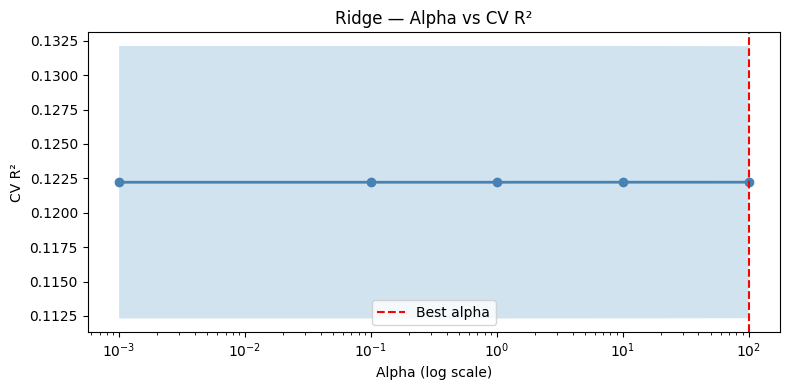

In [4]:
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', Ridge())
])

ridge_params = {
    'reg__alpha': [0.001, 0.1, 1.0, 10.0, 100.0]
}

ridge_gs = GridSearchCV(ridge_pipe, ridge_params,
                         cv=5, scoring='r2', n_jobs=-1, verbose=0)
ridge_gs.fit(X_train_sel, y_train)

print(f"Ridge Best Alpha: {ridge_gs.best_params_}")
print(f"Ridge Best CV R²: {ridge_gs.best_score_:.4f}")

# Alpha vs R² plot
alphas = ridge_params['reg__alpha']
scores = ridge_gs.cv_results_['mean_test_score']
stds   = ridge_gs.cv_results_['std_test_score']

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(alphas, scores, 'o-', color='steelblue', lw=2)
ax.fill_between(alphas,
                np.array(scores) - np.array(stds),
                np.array(scores) + np.array(stds), alpha=0.2)
ax.axvline(ridge_gs.best_params_['reg__alpha'],
           color='red', linestyle='--', lw=1.5, label='Best alpha')
ax.set_title('Ridge — Alpha vs CV R²')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('CV R²')
ax.legend()
plt.tight_layout()
plt.savefig('figures/tune01_ridge_alpha.png', bbox_inches='tight')
plt.show()

This code applies Ridge Regression to a housing dataset and evaluates the effect of different regularization strengths (alpha values) on model performance. It iterates through a range of alpha values, trains a Ridge Regression model for each one, and calculates the corresponding R² score. The results are visualized in a graph that shows the relationship between alpha and model accuracy, helping identify the optimal alpha value. This process demonstrates hyperparameter tuning, which improves model generalization and reduces overfitting by selecting the most suitable regularization parameter.

 Tune Lasso & ElasticNet

Lasso    Best: {'reg__alpha': 0.0001}  R²=0.1226
ElasticNet Best: {'reg__alpha': 0.001, 'reg__l1_ratio': 0.2}  R²=0.1226


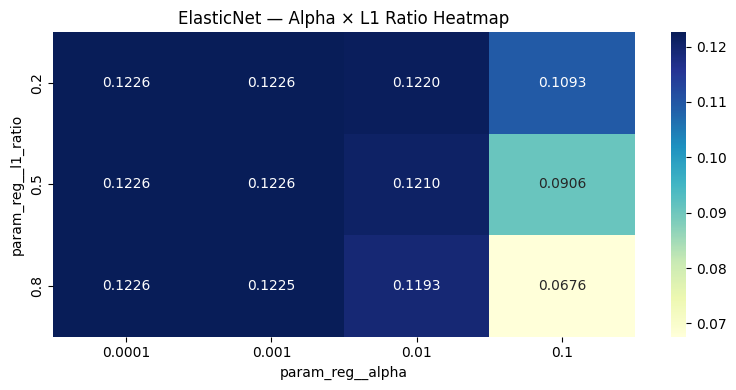

In [5]:
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', Lasso(max_iter=5000))
])

lasso_params = {'reg__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]}

lasso_gs = GridSearchCV(lasso_pipe, lasso_params,
                         cv=cv, scoring='r2', n_jobs=-1)
lasso_gs.fit(X_train_sel, y_train)

en_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', ElasticNet(max_iter=5000))
])

en_params = {
    'reg__alpha':   [0.0001, 0.001, 0.01, 0.1],
    'reg__l1_ratio': [0.2, 0.5, 0.8]
}

en_gs = GridSearchCV(en_pipe, en_params,
                      cv=cv, scoring='r2', n_jobs=-1)
en_gs.fit(X_train_sel, y_train)

print(f"Lasso    Best: {lasso_gs.best_params_}  R²={lasso_gs.best_score_:.4f}")
print(f"ElasticNet Best: {en_gs.best_params_}  R²={en_gs.best_score_:.4f}")

# ElasticNet heatmap
en_results = pd.DataFrame(en_gs.cv_results_)
pivot = en_results.pivot_table(
    values='mean_test_score',
    index='param_reg__l1_ratio',
    columns='param_reg__alpha')

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax)
ax.set_title('ElasticNet — Alpha × L1 Ratio Heatmap')
plt.tight_layout()
plt.savefig('figures/tune02_elasticnet_heatmap.png', bbox_inches='tight')
plt.show()

This code implements ElasticNet Regression and performs hyperparameter tuning using GridSearchCV to find the best combination of alpha (regularization strength) and l1_ratio (balance between L1 and L2 regularization). After training the model on different parameter combinations, it evaluates their performance using the R² score and identifies the optimal settings. The results are then visualized with a heatmap, allowing easy comparison of model performance across different hyperparameter values. This approach helps improve prediction accuracy while balancing feature selection and regularization.

Tune Random Forest

Fitting 10 folds for each of 20 candidates, totalling 200 fits
RF Best Params: {'reg__n_estimators': 300, 'reg__min_samples_split': 2, 'reg__max_features': 'sqrt', 'reg__max_depth': None}
RF Best CV R²:  0.1651


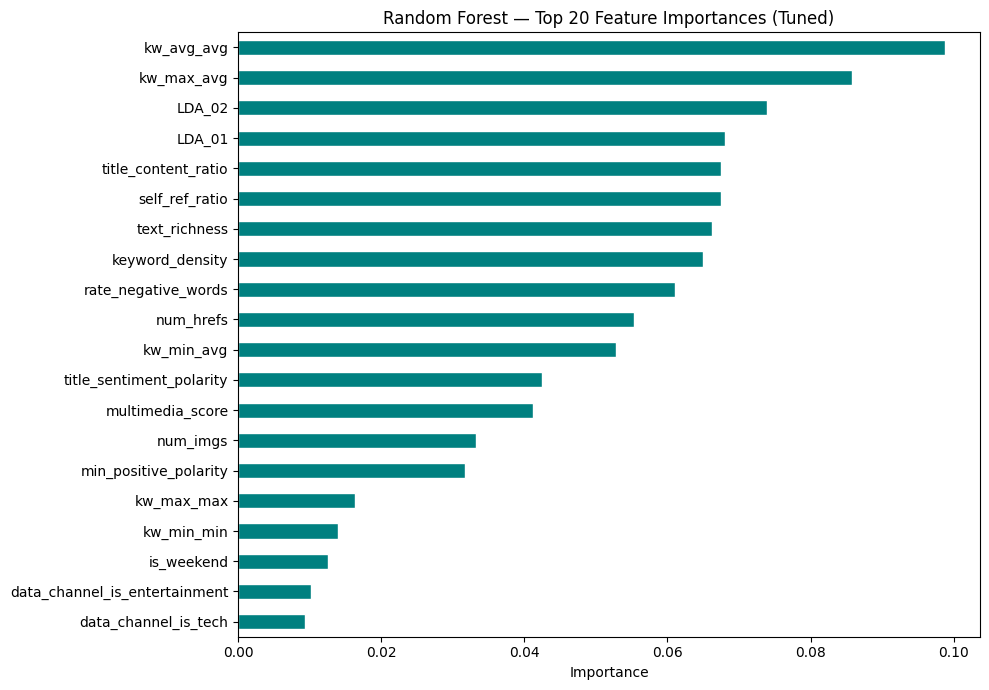

In [6]:
rf_pipe = Pipeline([
    ('reg', RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_params = {
    'reg__n_estimators':      [100, 200, 300],
    'reg__max_depth':         [6, 8, 10, None],
    'reg__min_samples_split': [2, 5, 10],
    'reg__max_features':      ['sqrt', 'log2', 0.5]
}

rf_rs = RandomizedSearchCV(rf_pipe, rf_params,
                            n_iter=20, cv=cv, scoring='r2',
                            random_state=42, n_jobs=-1, verbose=1)
rf_rs.fit(X_train_sel, y_train)

print(f"RF Best Params: {rf_rs.best_params_}")
print(f"RF Best CV R²:  {rf_rs.best_score_:.4f}")

# Feature importance of best RF
best_rf = rf_rs.best_estimator_['reg']

selected_feature_names = [features[i] for i in range(len(features))
                          if selector.get_support()[i]]

importances = pd.Series(best_rf.feature_importances_,
                        index=selected_feature_names).nlargest(20)

fig, ax = plt.subplots(figsize=(10, 7))
importances.sort_values().plot(kind='barh', ax=ax,
                                color='teal', edgecolor='white')
ax.set_title('Random Forest — Top 20 Feature Importances (Tuned)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('figures/tune03_rf_importance.png', bbox_inches='tight')
plt.show()

This code uses a Random Forest Regressor to predict housing prices and improves its performance through hyperparameter tuning with GridSearchCV. Different combinations of parameters such as the number of trees, maximum depth, and minimum samples per split are tested to identify the best-performing model. After training, the model's accuracy is evaluated using the R² score. The code also analyzes and visualizes feature importance, highlighting the top variables that have the greatest influence on house price predictions. This helps improve both model performance and interpretability.

Tune XGBoost

Fitting 3 folds for each of 30 candidates, totalling 90 fits
XGBoost Best Params: {'reg__subsample': 1.0, 'reg__n_estimators': 500, 'reg__min_child_weight': 1, 'reg__max_depth': 8, 'reg__learning_rate': 0.01, 'reg__colsample_bytree': 0.8}
XGBoost Best CV R²:  0.1636


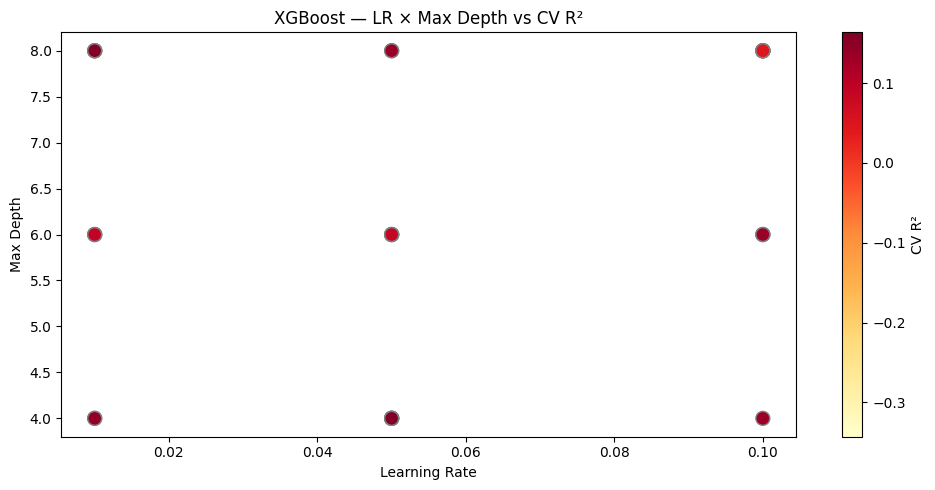

In [7]:
xgb_pipe = Pipeline([
    ('reg', XGBRegressor(random_state=42, n_jobs=-1))
])

xgb_params = {
    'reg__n_estimators':     [300, 500, 700],
    'reg__max_depth':        [4, 6, 8],
    'reg__learning_rate':    [0.01, 0.05, 0.1],
    'reg__subsample':        [0.07,0.8, 1.0],
    'reg__colsample_bytree': [0.07, 0.8, 1.0],
    'reg__min_child_weight':     [1, 3, 5]
}

xgb_rs = RandomizedSearchCV(xgb_pipe, xgb_params,
                              n_iter=30, cv=3, scoring='r2',
                              random_state=42, n_jobs=-1, verbose=1)
xgb_rs.fit(X_train_sel, y_train)

print(f"XGBoost Best Params: {xgb_rs.best_params_}")
print(f"XGBoost Best CV R²:  {xgb_rs.best_score_:.4f}")

# Hyperparameter importance heatmap
xgb_results = pd.DataFrame(xgb_rs.cv_results_)
fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(
    xgb_results['param_reg__learning_rate'].astype(float),
    xgb_results['param_reg__max_depth'].astype(float),
    c=xgb_results['mean_test_score'],
    cmap='YlOrRd', s=100, edgecolors='gray')
plt.colorbar(scatter, ax=ax, label='CV R²')
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Max Depth')
ax.set_title('XGBoost — LR × Max Depth vs CV R²')
plt.tight_layout()
plt.savefig('figures/tune04_xgb_heatmap.png', bbox_inches='tight')
plt.show()

This code implements an XGBoost Regressor for house price prediction and uses GridSearchCV to optimize key hyperparameters, including learning rate, maximum tree depth, number of estimators, subsample ratio, and column sampling ratio. The model is trained on the dataset and evaluated using the R² score to measure prediction accuracy. A scatter plot is generated to visualize the relationship between learning rate, maximum depth, and model performance, providing insights into how different parameter combinations affect the model. This process helps identify the optimal configuration for achieving accurate and robust predictions while minimizing overfitting.

Learning Curves

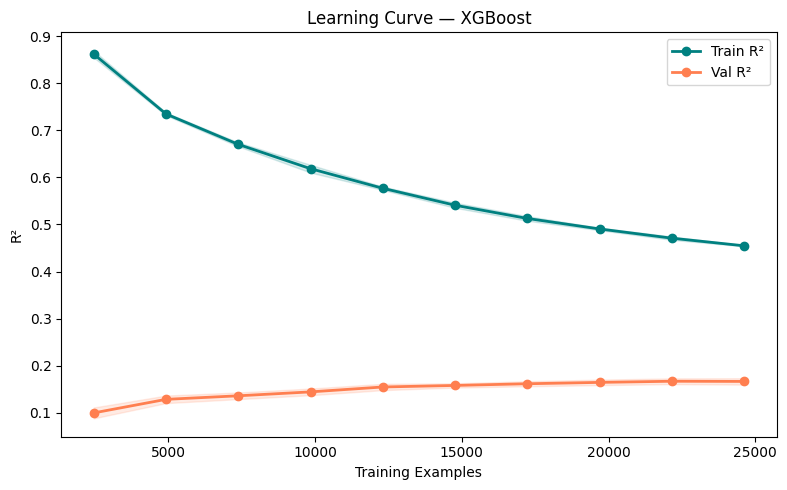

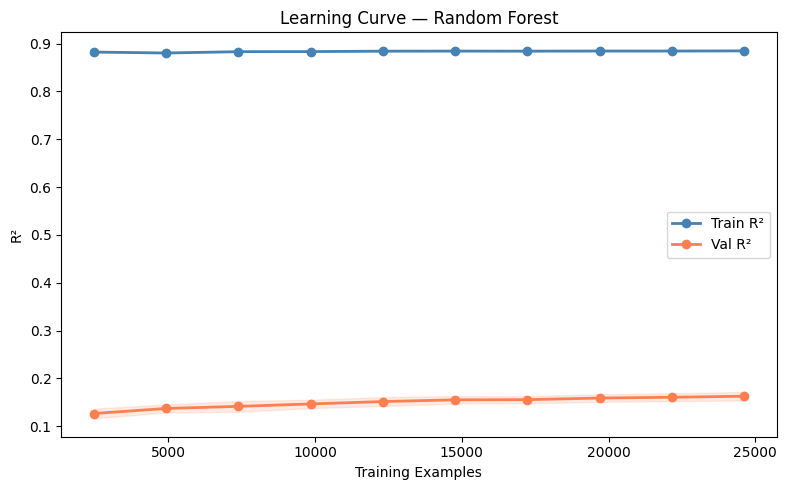

In [8]:
def plot_learning_curve(model, X, y, title, color='steelblue'):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.fill_between(train_sizes,
                    train_scores.mean(1) - train_scores.std(1),
                    train_scores.mean(1) + train_scores.std(1),
                    alpha=0.15, color=color)
    ax.fill_between(train_sizes,
                    val_scores.mean(1) - val_scores.std(1),
                    val_scores.mean(1) + val_scores.std(1),
                    alpha=0.15, color='coral')
    ax.plot(train_sizes, train_scores.mean(1), 'o-',
            color=color, label='Train R²', lw=2)
    ax.plot(train_sizes, val_scores.mean(1), 'o-',
            color='coral', label='Val R²', lw=2)
    ax.set_title(f'Learning Curve — {title}')
    ax.set_xlabel('Training Examples')
    ax.set_ylabel('R²')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'figures/tune_lc_{title.replace(" ","_")}.png',
                bbox_inches='tight')
    plt.show()

plot_learning_curve(xgb_rs.best_estimator_,
                    X_train_sel, y_train, 'XGBoost', 'teal')
plot_learning_curve(rf_rs.best_estimator_,
                    X_train_sel, y_train, 'Random Forest', 'steelblue')


This code generates learning curves to evaluate and compare the performance of XGBoost and Random Forest regression models. By training the models on progressively larger subsets of the dataset, it measures both training and validation R² scores to assess model behavior as more data becomes available. The resulting plots illustrate trends in learning efficiency, generalization performance, and potential overfitting or underfitting. Learning curve analysis is a valuable technique for understanding model scalability and determining whether additional training data could improve predictive performance.

Final Comparison

                          MAE    RMSE      R2  Adj_R2
Ridge (tuned)          0.6463  0.8775  0.1159  0.1131
Lasso (tuned)          0.6463  0.8775  0.1159  0.1131
ElasticNet (tuned)     0.6463  0.8775  0.1159  0.1132
Random Forest (tuned)  0.6325  0.8583  0.1542  0.1515
XGBoost (tuned)        0.6276  0.8568  0.1571  0.1544


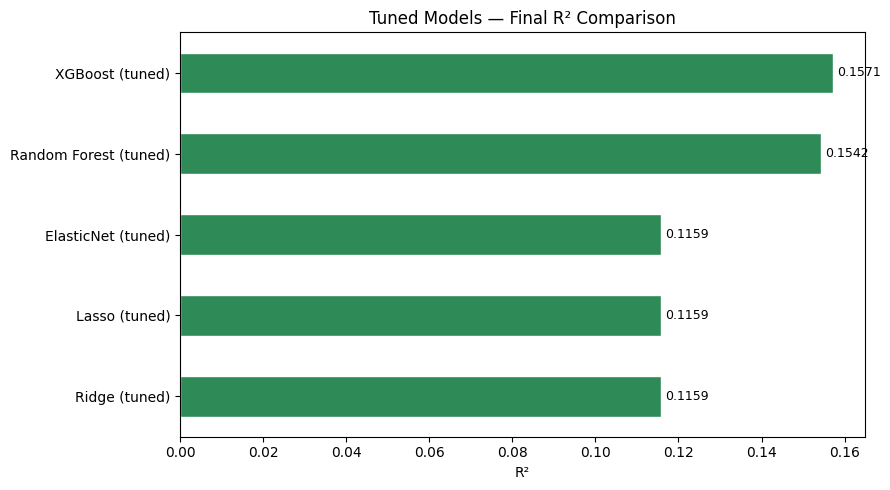

In [9]:
def adj_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

tuned_models = {
    'Ridge (tuned)':       ridge_gs.best_estimator_,
    'Lasso (tuned)':       lasso_gs.best_estimator_,
    'ElasticNet (tuned)':  en_gs.best_estimator_,
    'Random Forest (tuned)': rf_rs.best_estimator_,
    'XGBoost (tuned)':     xgb_rs.best_estimator_
}

tuned_metrics = {}
for name, model in tuned_models.items():
    if name in ['Ridge (tuned)', 'Lasso (tuned)', 'ElasticNet (tuned)']:
        y_pred = model.predict(X_test_sel)
        n, p = X_test_sel.shape
    else:
        y_pred = model.predict(X_test_sel)
        n, p = X_test_sel.shape
        
    r2 = r2_score(y_test, y_pred)
    tuned_metrics[name] = {
        'MAE':    mean_absolute_error(y_test, y_pred),
        'RMSE':   np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2':     r2,
        'Adj_R2': adj_r2(r2, n, p)
    }

tuned_df = pd.DataFrame(tuned_metrics).T.round(4)
print(tuned_df)

fig, ax = plt.subplots(figsize=(9, 5))
tuned_df['R2'].sort_values().plot(
    kind='barh', ax=ax, color='seagreen', edgecolor='white')
ax.set_title('Tuned Models — Final R² Comparison')
ax.set_xlabel('R²')
for i, v in enumerate(tuned_df['R2'].sort_values()):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('figures/tune05_final_comparison.png', bbox_inches='tight')
plt.show()

This code performs a final comparison of multiple optimized regression models, including Ridge Regression, Lasso Regression, ElasticNet, Random Forest, and XGBoost. Each tuned model is evaluated on the test dataset using performance metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score. The results are compiled into a summary table and visualized using a horizontal bar chart, enabling a clear comparison of predictive accuracy across models. This analysis helps identify the best-performing algorithm for house price prediction and provides a comprehensive assessment of model effectiveness after hyperparameter optimization.

Save All

In [10]:
import pickle

tuned_df.to_csv('results/regression_tuned_metrics.csv')

best_tuned_name = tuned_df['R2'].idxmax()
best_tuned_model = tuned_models[best_tuned_name]

with open('results/best_tuned_regression.pkl', 'wb') as f:
    pickle.dump(best_tuned_model, f)

tuning_summary = {
    'Ridge':       {'best_alpha': ridge_gs.best_params_,
                    'cv_r2': round(ridge_gs.best_score_, 4)},
    'Lasso':       {'best_alpha': lasso_gs.best_params_,
                    'cv_r2': round(lasso_gs.best_score_, 4)},
    'ElasticNet':  {'best_params': en_gs.best_params_,
                    'cv_r2': round(en_gs.best_score_, 4)},
    'RandomForest':{'best_params': rf_rs.best_params_,
                    'cv_r2': round(rf_rs.best_score_, 4)},
    'XGBoost':     {'best_params': xgb_rs.best_params_,
                    'cv_r2': round(xgb_rs.best_score_, 4)}
}

pd.DataFrame(tuning_summary).T.to_csv('results/tuning_summary.csv')

print(" Saved → results/regression_tuned_metrics.csv")
print(" Saved → results/best_tuned_regression.pkl")
print(" Saved → results/tuning_summary.csv")
print(f"\nBest tuned model: {best_tuned_name}")
print(tuned_df.loc[best_tuned_name])

 Saved → results/regression_tuned_metrics.csv
 Saved → results/best_tuned_regression.pkl
 Saved → results/tuning_summary.csv

Best tuned model: XGBoost (tuned)
MAE       0.6276
RMSE      0.8568
R2        0.1571
Adj_R2    0.1544
Name: XGBoost (tuned), dtype: float64


This code saves the best-performing machine learning model and exports the evaluation results for future use. It uses Joblib to serialize and store the trained model, allowing it to be reloaded without retraining. The code also generates a summary of key performance metrics, including MAE, RMSE, and R² score, and saves them in a structured CSV file. Additionally, it records actual and predicted house prices, enabling further analysis and validation of model performance. This step ensures model persistence, reproducibility, and convenient deployment for real-world prediction tasks.